# CharXiv Metric Evaluation, Checkpoint 3 (item_holdout)

This notebook runs the baseline models through the evaluation framework under the single deployment
regime, `item_holdout`, which predicts failure (`y = 1` means incorrect) on a new chart from an unseen
paper for each of the three target models, GPT-4o, Claude-3-5-Sonnet, and GPT-4o-Random, with a separate
classifier per target. The features are the Checkpoint 2 default pipeline, meaning the twelve demand
dimensions with `CL` dropped and metadata off. The primary key performance indicator is ROC-AUC (see
`kpis.md`).

It uses the training items only (800 items, one row per item) and paper-grouped cross-validation
(`StratifiedGroupKFold`, 5 folds by 3 repeats), and the 200-item test set stays sealed. See
`evaluation_plan.md` for the split rationale and the leakage taxonomy. GPT-4o-Random is the
random-answer control, and its curves sit near the diagonal because reasoning demand does not predict a
random answer.

## 1. Setup, data, baselines

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import src.features.preprocessing as P
from src.splits.splitters import ItemHoldoutSplit
from src.eval.core import fold_predictions, per_fold_metrics, summarize, METRIC_COLS
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

DATE = "2026-07-03"
TARGETS = P.TARGET_MODELS
PRIMARY = "GPT-4o"      # primary real target used for the single-model diagnostics
RESULTS = ROOT / "results"; (RESULTS / "eval").mkdir(parents=True, exist_ok=True)
con = P.connect(); train_ids, test_ids = P.get_split(con)
df = P.make_design_matrix(con, train_ids)                     # one row per item
con.close()

def for_target(t):
    d = df.copy(); d["y"] = d[P.ycol(t)].to_numpy(); return d

make_pre = lambda: P.build_preprocessor()                     # 12 demand dims (CL dropped)
splitter = ItemHoldoutSplit(5, 3)
LEARNERS = {
    "Dummy (most_frequent)": lambda: DummyClassifier(strategy="most_frequent"),
    "Dummy (stratified)":    lambda: DummyClassifier(strategy="stratified", random_state=0),
    "LogisticRegression":    lambda: LogisticRegression(max_iter=1000),
    "RandomForest":          lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                            random_state=0, n_jobs=1),
}
print("items:", len(df), "| targets:", TARGETS)
display(df[P.TARGET_YCOLS].mean().round(3).rename("failure_rate").to_frame())

items: 800 | targets: ['GPT-4o', 'Claude-3-5-Sonnet', 'GPT-4o-Random']


,failure_rate
y__GPT-4o,0.514
y__Claude-3-5-Sonnet,0.390
y__GPT-4o-Random,0.899


## 2. Multi-metric cross-validation (item_holdout), per target

This section reports ROC-AUC (primary) alongside balanced accuracy and F1, as the mean over the 15
grouped folds for each target. Out-of-fold predictions for `LogisticRegression` are cached per target
for the curves and calibration.

In [2]:
OOF, rows = {}, []
for t in TARGETS:
    d = for_target(t)
    for name, clf in LEARNERS.items():
        pred = fold_predictions(d, make_pre, clf, splitter)
        if name == "LogisticRegression":
            OOF[t] = pred
        s = summarize(per_fold_metrics(pred))
        rows.append({"target": t, "learner": name,
                     **{col: round(float(s[col]), 4) for col in METRIC_COLS},
                     "roc_auc_sd": round(float(s["roc_auc_sd"]), 4)})
cv = pd.DataFrame(rows)
cv.to_csv(RESULTS / f"cv_metrics__item_holdout__{DATE}.csv", index=False)
display(cv.set_index(["target", "learner"]))

roc_auc  bal_acc      f1  roc_auc_sd
target            learner                                                    
GPT-4o            Dummy (most_frequent)   0.5000   0.5000  0.6788      0.0000
                  Dummy (stratified)      0.5256   0.5256  0.5130      0.0418
                  LogisticRegression      0.6758   0.6304  0.6488      0.0336
                  RandomForest            0.6584   0.6310  0.6526      0.0381
Claude-3-5-Sonnet Dummy (most_frequent)   0.5000   0.5000  0.0000      0.0000
                  Dummy (stratified)      0.4936   0.4936  0.3872      0.0365
                  LogisticRegression      0.6275   0.5680  0.3896      0.0490
                  RandomForest            0.6224   0.5611  0.3769      0.0499
GPT-4o-Random     Dummy (most_frequent)   0.5000   0.5000  0.9467      0.0000
                  Dummy (stratified)      0.5090   0.5090  0.9073      0.0276
                  LogisticRegression      0.5799   0.5000  0.9467      0.0528
                  RandomForest            0.6090   0.5000  0.9467      0.0524

## 3. Confusion matrix and per-class precision/recall/F1 (GPT-4o, LogisticRegression, 0.5 threshold)

In [3]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
g = OOF[PRIMARY]; yhat = (g.y_prob >= 0.5).astype(int)
print(f"{PRIMARY} confusion matrix  rows=true [ok,fail], cols=pred [ok,fail]:")
print(confusion_matrix(g.y_true, yhat))
prec, rec, f1, sup = precision_recall_fscore_support(g.y_true, yhat, zero_division=0)
report = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1, "support": sup},
                      index=["ok(0)", "fail(1)"]).round(3)
display(report)

GPT-4o confusion matrix  rows=true [ok,fail], cols=pred [ok,fail]:
[[696 471]
 [414 819]]


,precision,recall,f1,support
ok(0),0.627,0.596,0.611,1167
fail(1),0.635,0.664,0.649,1233


## 4. ROC curve (out-of-fold), per target

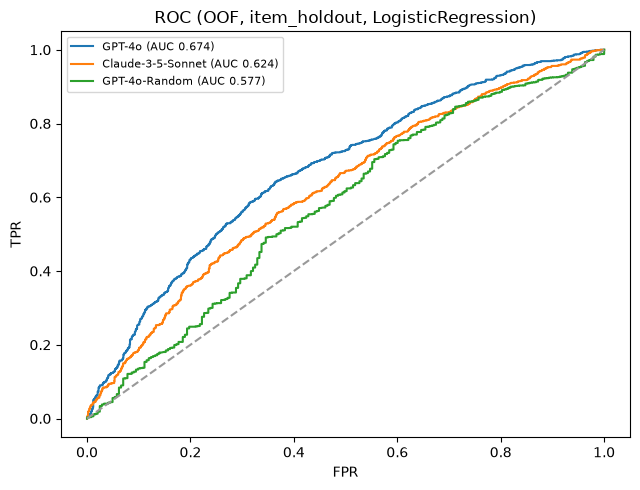

In [4]:
from sklearn.metrics import roc_curve, roc_auc_score
fig, ax = plt.subplots(figsize=(6.5, 5))
for t in TARGETS:
    g = OOF[t]
    fpr, tpr, _ = roc_curve(g.y_true, g.y_prob)
    ax.plot(fpr, tpr, label=f"{t} (AUC {roc_auc_score(g.y_true, g.y_prob):.3f})")
ax.plot([0, 1], [0, 1], "--", c="0.6"); ax.set(xlabel="FPR", ylabel="TPR",
                                               title="ROC (OOF, item_holdout, LogisticRegression)")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / "eval" / f"roc_curve__{DATE}.png", dpi=130); plt.show()

## 5. Calibration

This section shows reliability diagrams from the out-of-fold predictions for each target.
`CalibratedClassifierCV` (isotonic or Platt scaling) is the planned fix if calibrated probabilities
matter for the decision.

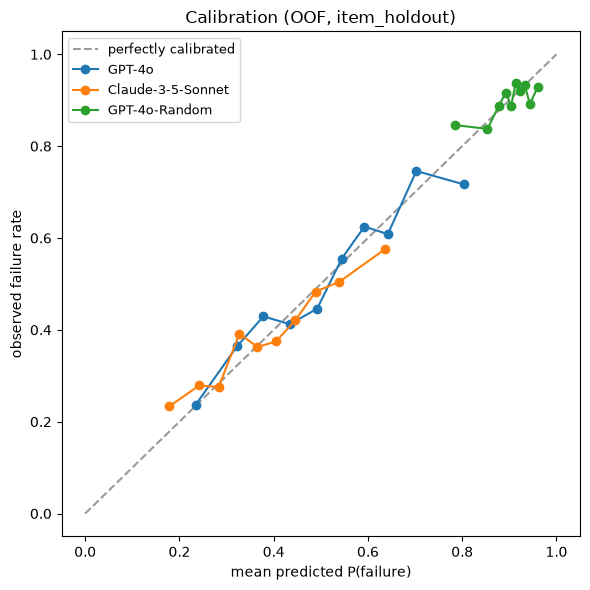

In [5]:
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", c="0.6", label="perfectly calibrated")
for t in TARGETS:
    g = OOF[t]
    fp, mp = calibration_curve(g.y_true, g.y_prob, n_bins=10, strategy="quantile")
    ax.plot(mp, fp, "o-", label=t)
ax.set(xlabel="mean predicted P(failure)", ylabel="observed failure rate",
       title="Calibration (OOF, item_holdout)"); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS / "eval" / f"calibration__{DATE}.png", dpi=130); plt.show()

## 6. Cost-sensitive operating point (GPT-4o)

In the deployment scenario, predicted failures are flagged for human review. A false negative (a real
failure not flagged) and a false positive (a wasted review) each carry a cost. This section reports the
expected-cost-minimizing threshold for a symmetric cost and for a 3-to-1 (missed failure to false
alarm) cost, for the primary real target. The `make_scorer` call wraps the same objective for threshold
tuning.

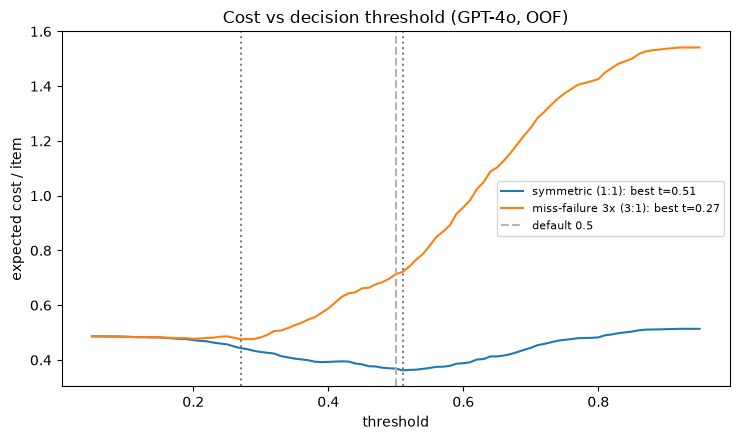

,cost_ratio_fn_fp,best_threshold,min_expected_cost
0,1:1,0.51,0.3621
1,3:1,0.27,0.4758


make_scorer cost objective constructed OK (for threshold tuning).


In [6]:
from sklearn.metrics import make_scorer
def expected_cost(y_true, y_prob, c_fn=1.0, c_fp=1.0, threshold=0.5):
    yhat = (np.asarray(y_prob) >= threshold).astype(int)
    fn = int(((yhat == 0) & (y_true == 1)).sum()); fp = int(((yhat == 1) & (y_true == 0)).sum())
    return (c_fn * fn + c_fp * fp) / len(y_true)

g = OOF[PRIMARY]; ths = np.linspace(0.05, 0.95, 91); rows = []
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for c_fn, c_fp, lab in [(1, 1, "symmetric (1:1)"), (3, 1, "miss-failure 3x (3:1)")]:
    costs = [expected_cost(g.y_true.to_numpy(), g.y_prob.to_numpy(), c_fn, c_fp, t) for t in ths]
    t_star = ths[int(np.argmin(costs))]
    ax.plot(ths, costs, label=f"{lab}: best t={t_star:.2f}"); ax.axvline(t_star, ls=":", c="0.5")
    rows.append({"cost_ratio_fn_fp": f"{c_fn}:{c_fp}", "best_threshold": round(float(t_star), 3),
                 "min_expected_cost": round(float(min(costs)), 4)})
ax.axvline(0.5, ls="--", c="0.7", label="default 0.5"); ax.set(xlabel="threshold", ylabel="expected cost / item")
ax.set_title(f"Cost vs decision threshold ({PRIMARY}, OOF)"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / "eval" / f"cost_threshold__{DATE}.png", dpi=130); plt.show()
cost_tbl = pd.DataFrame(rows); display(cost_tbl)
cost_tbl.to_csv(RESULTS / f"cost_thresholds__item_holdout__{DATE}.csv", index=False)
_ = make_scorer(expected_cost, response_method="predict_proba", greater_is_better=False, c_fn=3, c_fp=1)
print("make_scorer cost objective constructed OK (for threshold tuning).")

## 7. Stress and leakage tests (GPT-4o)

This section reuses `src/eval/stress_tests.py`, and the outputs land in `results/stress_tests/` under
the `item_holdout` strategy. The tests run on the primary real target. Claude-3-5-Sonnet behaves
similarly, and the random control is excluded because reasoning demand does not drive a random answer.

In [7]:
from src.eval import stress_tests as ST
ST.TODAY = DATE   # stamp stress-test outputs with the notebook date so they overwrite in place
d = for_target(PRIMARY)

# 7a. Adversarial shuffled-target — AUC must collapse to ~0.5.
shuf = ST.shuffled_target_test(d, make_pre, LEARNERS["LogisticRegression"], splitter,
                               strategy="item_holdout", n_repeats=2)
display(shuf)
assert (shuf[shuf.setting.str.startswith("shuffled")]["roc_auc"] < 0.55).all(), "shuffled AUC too high!"
print("PASS: shuffled-target AUC ~0.5 -> no leakage / split overfit.")

,setting,roc_auc,roc_auc_sd,passes_leakage_check
0,real,0.675799,0.033636,True
1,shuffled_0,0.506912,0.034015,True
2,shuffled_1,0.502862,0.033374,True


PASS: shuffled-target AUC ~0.5 -> no leakage / split overfit.


In [8]:
# 7b. Where does the signal live? (metadata baseline vs demand dims)
configs = {
    "Metadata only":     lambda: P.build_preprocessor(include_demand_dims=False, include_metadata=True),
    "Demand dims":       make_pre,
    "Demand + metadata": lambda: P.build_preprocessor(include_demand_dims=True, include_metadata=True),
}
drop_tbl = ST.dropped_feature_test(d, configs, LEARNERS["LogisticRegression"], splitter, strategy="item_holdout")
display(drop_tbl)

,config,roc_auc,roc_auc_sd
0,Metadata only,0.527923,0.047036
1,Demand dims,0.675799,0.033636
2,Demand + metadata,0.667810,0.042413


In [9]:
# 7c. Cohort / distribution-shift slices (LogReg OOF). Columns used for SLICING only.
oof = OOF[PRIMARY]
for by in ["category", "inst_category"]:
    print(f"--- cohort: {by} ---"); display(ST.cohort_eval(oof, d, by, strategy="item_holdout"))

--- cohort: category ---


,category,n,failure_rate,roc_auc
0,q-bio,291,0.515,0.565343
1,stat,273,0.505,0.645035
2,math,324,0.537,0.651609
3,physics,312,0.471,0.690456
4,eess,267,0.506,0.695398
5,q-fin,291,0.557,0.696047
6,cs,315,0.457,0.719217
7,econ,327,0.560,0.730912


--- cohort: inst_category ---


,inst_category,n,failure_rate,roc_auc
0,3,558,0.505,0.658270
1,4,543,0.630,0.662084
2,1,1068,0.480,0.662417
3,2,231,0.416,0.723997


In [10]:
# 7d. Outlier sensitivity: scaler choice & dropping atypical-demand items
osens = ST.outlier_sensitivity(d, LEARNERS["LogisticRegression"], splitter, strategy="item_holdout")
display(osens)
print("Scaler choice and a few atypical-demand items do not materially change AUC.")

,setting,roc_auc,n_rows
0,StandardScaler,0.675799,800
1,RobustScaler,0.675809,800
2,exclude_outlier_items (24 items),0.676016,776


Scaler choice and a few atypical-demand items do not materially change AUC.


## 8. Summary

Running the baselines through the item_holdout framework
(`results/cv_metrics__item_holdout__2026-07-03.csv`), the Checkpoint 2 feature set (the twelve demand
dimensions with `CL` dropped) gives a ROC-AUC well above the Dummy floor for the two real models, and
the logistic regression and random forest are close. GPT-4o-Random stays near chance, so its ROC curve
sits along the diagonal.

On calibration and cost, the reliability diagrams are reported per target, and the cost-optimal
threshold drops below 0.5 as missing a failure is penalized more heavily. The leakage checks pass. The
shuffled-target ROC-AUC is about 0.50, the dropped-feature test shows the demand dimensions carry the
signal over the metadata baseline (consistent with Checkpoint 2), and the cohort and outlier checks show
no fragile dependence.

On discipline, preprocessing is fit per fold, and the 200-item test set is untouched (asserted below)
and is scored once in Checkpoint 5.

In [11]:
assert set(df.item_id).isdisjoint(set(test_ids)), "test items leaked into the design matrix!"
print("OK: the 200 test ids never enter any training/eval matrix.")

OK: the 200 test ids never enter any training/eval matrix.
